# 02 - Preprocessing & Dimensionality Reduction

This notebook applies QC filtering, normalization, HVG selection, and dimensionality reduction to PBMC scRNA-seq data according to the pre-registered protocol.

## 1. Setup

Import required libraries and configure environment.

Set random seeds: np.random.seed(42), random.seed(42). Set scanpy settings: verbosity=3, dpi_save=300.

Load pipeline.yaml, qc.yaml, clustering.yaml, markers.yaml from ../config/. Print config parameters to verify correct values.

Import libraries: scanpy, numpy, matplotlib, pandas, yaml, pathlib. Configure scanpy verbosity, matplotlib backend, and warnings.

In [ ]:
import scanpy as sc
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import random

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=300, dpi_save=300)

config_dir = Path('../config')

config_files = {
    "clustering": "clustering.yaml",
    "qc": "qc.yaml",
    "markers": "markers.yaml",
    "pipeline": "pipeline.yaml"
}

config = {}

for key, filename in config_files.items():
    with open(config_dir / filename, 'r') as f:
        config[key] = yaml.safe_load(f)

random_seed = config['pipeline']['random_seed']
np.random.seed(random_seed)
random.seed(random_seed)
sc.settings.seed = random_seed

for section, params in config.items():
    print(f"\n=== {section.upper()} ===")
    print(yaml.dump(params, sort_keys=False))


=== CLUSTERING ===
n_hvgs: 2000
hvg_flavor: seurat
n_pcs: 40
n_neighbors: 15
resolutions:
- 0.5
- 1.0
- 1.5
primary_resolution: 1.0
random_seed: 42
metric: euclidean


=== QC ===
min_genes: 300
max_genes: 2500
max_mito_pct: 10
min_cells_per_gene: 3


=== MARKERS ===
t_cells:
- CD3D
- CD3E
cd4_t:
- IL7R
- CCR7
cd8_t:
- CD8A
- GZMA
nk:
- NKG7
- GNLY
b_cells:
- MS4A1
- CD79A
monocytes:
- CD14
- FCGR3A
- LST1
dendritic_cells:
- HLA-DRA
- ITGAX
platelets:
- PPBP
- PF4


=== PIPELINE ===
normalization:
  target_sum: 10000
  log_transform: true
scaling:
  regress_out:
  - pct_counts_mt
de_analysis:
  test: wilcoxon
  correction: benjamini-hochberg
  min_log2fc: 0.25
  min_pct: 0.25
  alpha: 0.05
random_seed: 42
reproducibility:
  deterministic: true



## 2. Load QC-Annotated Data

Load the QC-annotated data with existing quality metrics from `data/processed/pbmc_qc_metrics.h5ad`.

Print data shape. Verify QC metrics exist: n_genes, n_counts, pct_counts_mt.

In [41]:
adata = sc.read_h5ad('../data/processed/pbmc_qc_metrics.h5ad')
print(f"Data shape: {adata.shape}")
print(f"Obs columns: {adata.obs.columns}")
print(f"Var columns: {adata.var.columns}")

Data shape: (2752, 54950)
Obs columns: Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo'],
      dtype='object')
Var columns: Index(['gene_ids', 'feature_types', 'genome', 'mt', 'ribo',
       'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts',
       'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'],
      dtype='object')


## 3. Apply QC Filters

Apply the pre-registered QC thresholds:
- **min_genes**: 300
- **max_genes**: 2500
- **max_mito_pct**: 10%
- **min_cells_per_gene**: 3

No post-hoc adjustment allowed.

Assert <25% cells removed (FAILURE CRITERION).

Calculate and print filtering results: cells removed (count and %), genes removed (count and %), final shape

Filter cells based on QC thresholds: min_genes=300, max_genes=2500, max_mito_pct=10

Filter genes: min_cells_per_gene = 3

Store original cell count before filtering.

In [42]:
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[
    (adata.obs["n_genes_by_counts"] >= 300) &
    (adata.obs["n_genes_by_counts"] <= 2500) &
    (adata.obs["pct_counts_mt"] < 10),
    :
]
print(adata.shape)

filtered out 34724 genes that are detected in less than 3 cells
(2719, 20226)


## 4. Normalization

Library size normalization to target sum of 10,000 followed by log1p transformation.

Store normalized counts in .raw before subsequent transformations.

Apply log1p transformation.

Normalize library size to target sum 10,000.

In [43]:
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


## 5. Highly Variable Genes

Select 2000 highly variable genes using Seurat flavor for feature selection.

Plot HVG selection scatter and save to results/qc/figures/hvg_selection.png

Print number of HVGs selected.

Subset to selected HVGs only.

Select 2000 highly variable genes using Seurat flavor.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
2000


<Axes: xlabel='mean expressions of genes', ylabel='dispersions of genes (not normalized)'>

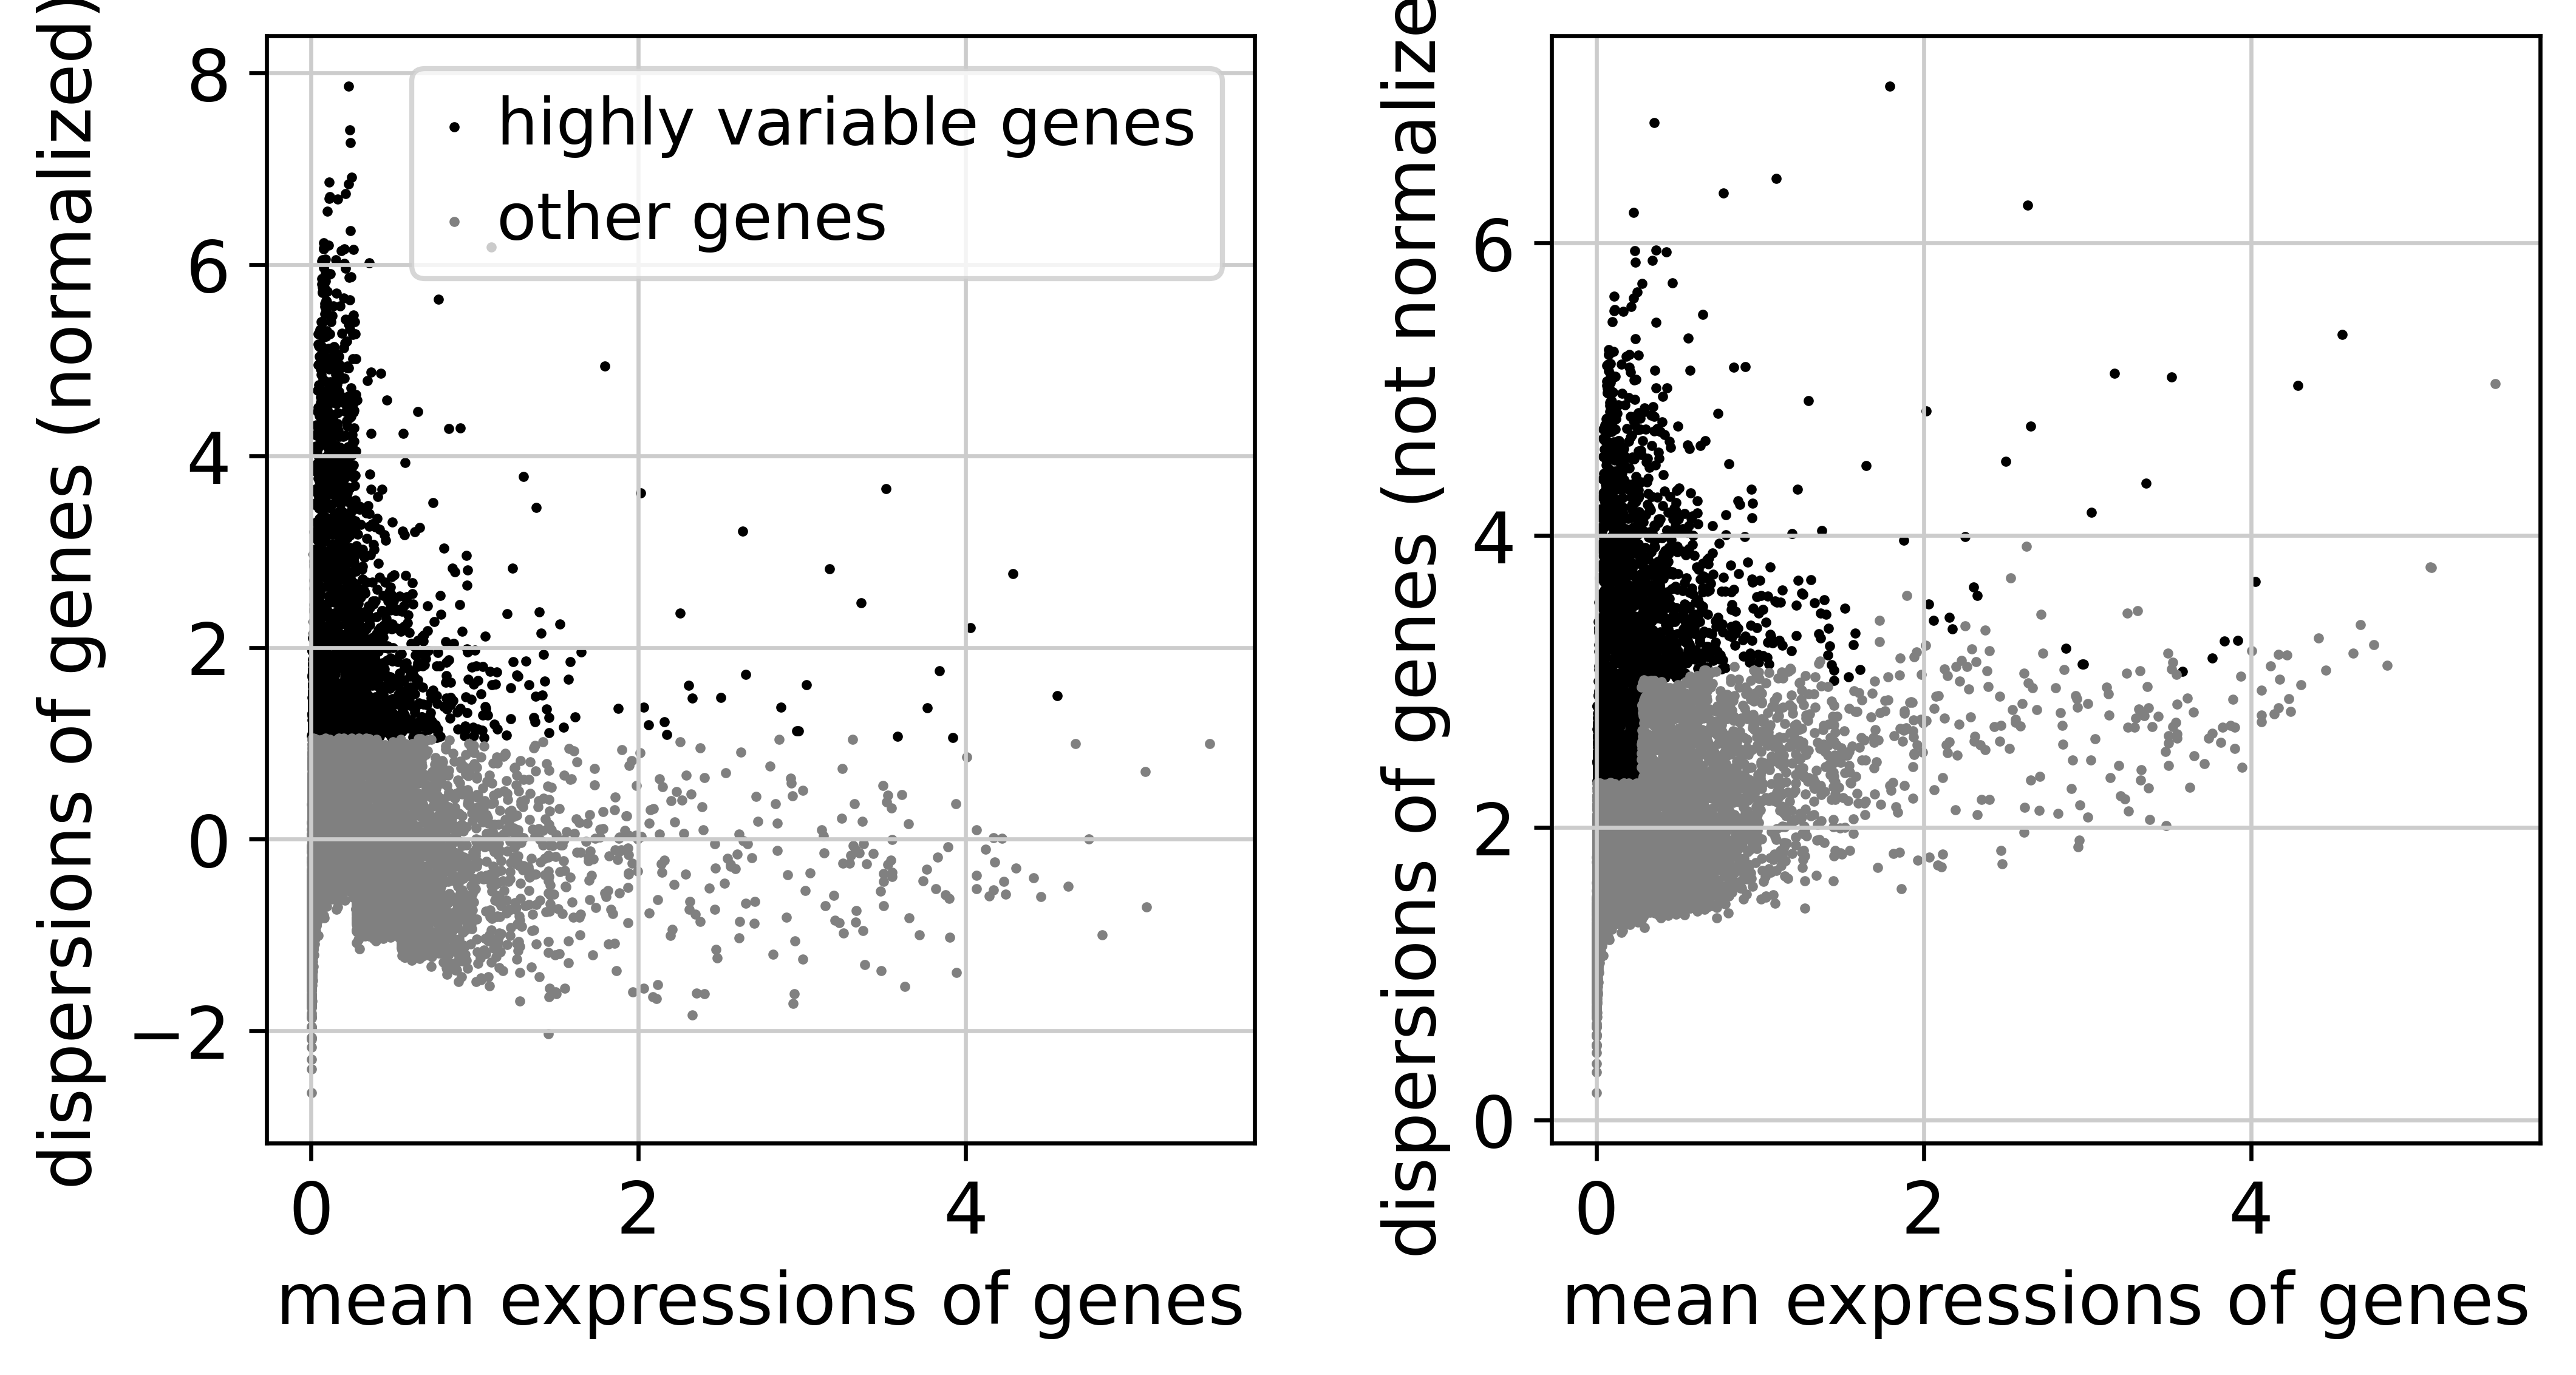

In [44]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
print(adata.var['highly_variable'].sum())

sc.pl.highly_variable_genes(adata, show=False)


## 6. Scaling & Regression

Regress out mitochondrial percentage (NOT total counts per decision log) and scale to unit variance.

Scale to unit variance with max_value=10.

Regress out pct_counts_mt only (NOT total_counts per decision log).

In [45]:
sc.pp.regress_out(adata, ['pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

regressing out ['pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:01:08)


## 7. PCA

Reduce dimensionality using 40 principal components with fixed random seed (precommitted value).

Create PCA scatter plots (PC1 vs PC2) colored by n_genes, total_counts, pct_counts_mt and save to results/pca/

Plot elbow plot (variance ratio by PC) and save to results/pca/pca_variance_ratio.png

Print cumulative variance explained by top 10 PCs.

Compute PCA with 40 components and random_state=42.

Assert n_vars matches n_hvgs (2000) before PCA.

In [46]:
adata = adata[:, adata.var["highly_variable"]]
assert adata.n_vars == 2000

In [47]:
sc.pp.pca(adata, svd_solver='arpack', n_comps=40)

computing PCA
    with n_comps=40


    finished (0:00:03)


/home/godfather/2026_bio_projects/pbmc_scRNA_clustering_markers/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:325: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca


In [48]:
var_ratio = adata.uns["pca"]["variance_ratio"]
print("Cumulative variance (top 10 PCs):", np.sum(var_ratio[:10]))

Cumulative variance (top 10 PCs): 0.05838003810905913


In [49]:
sc.pl.pca(
    adata,
    color=["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    show=False
)
plt.savefig("../results/pca/pca_scatter.png", dpi=300)
plt.close()

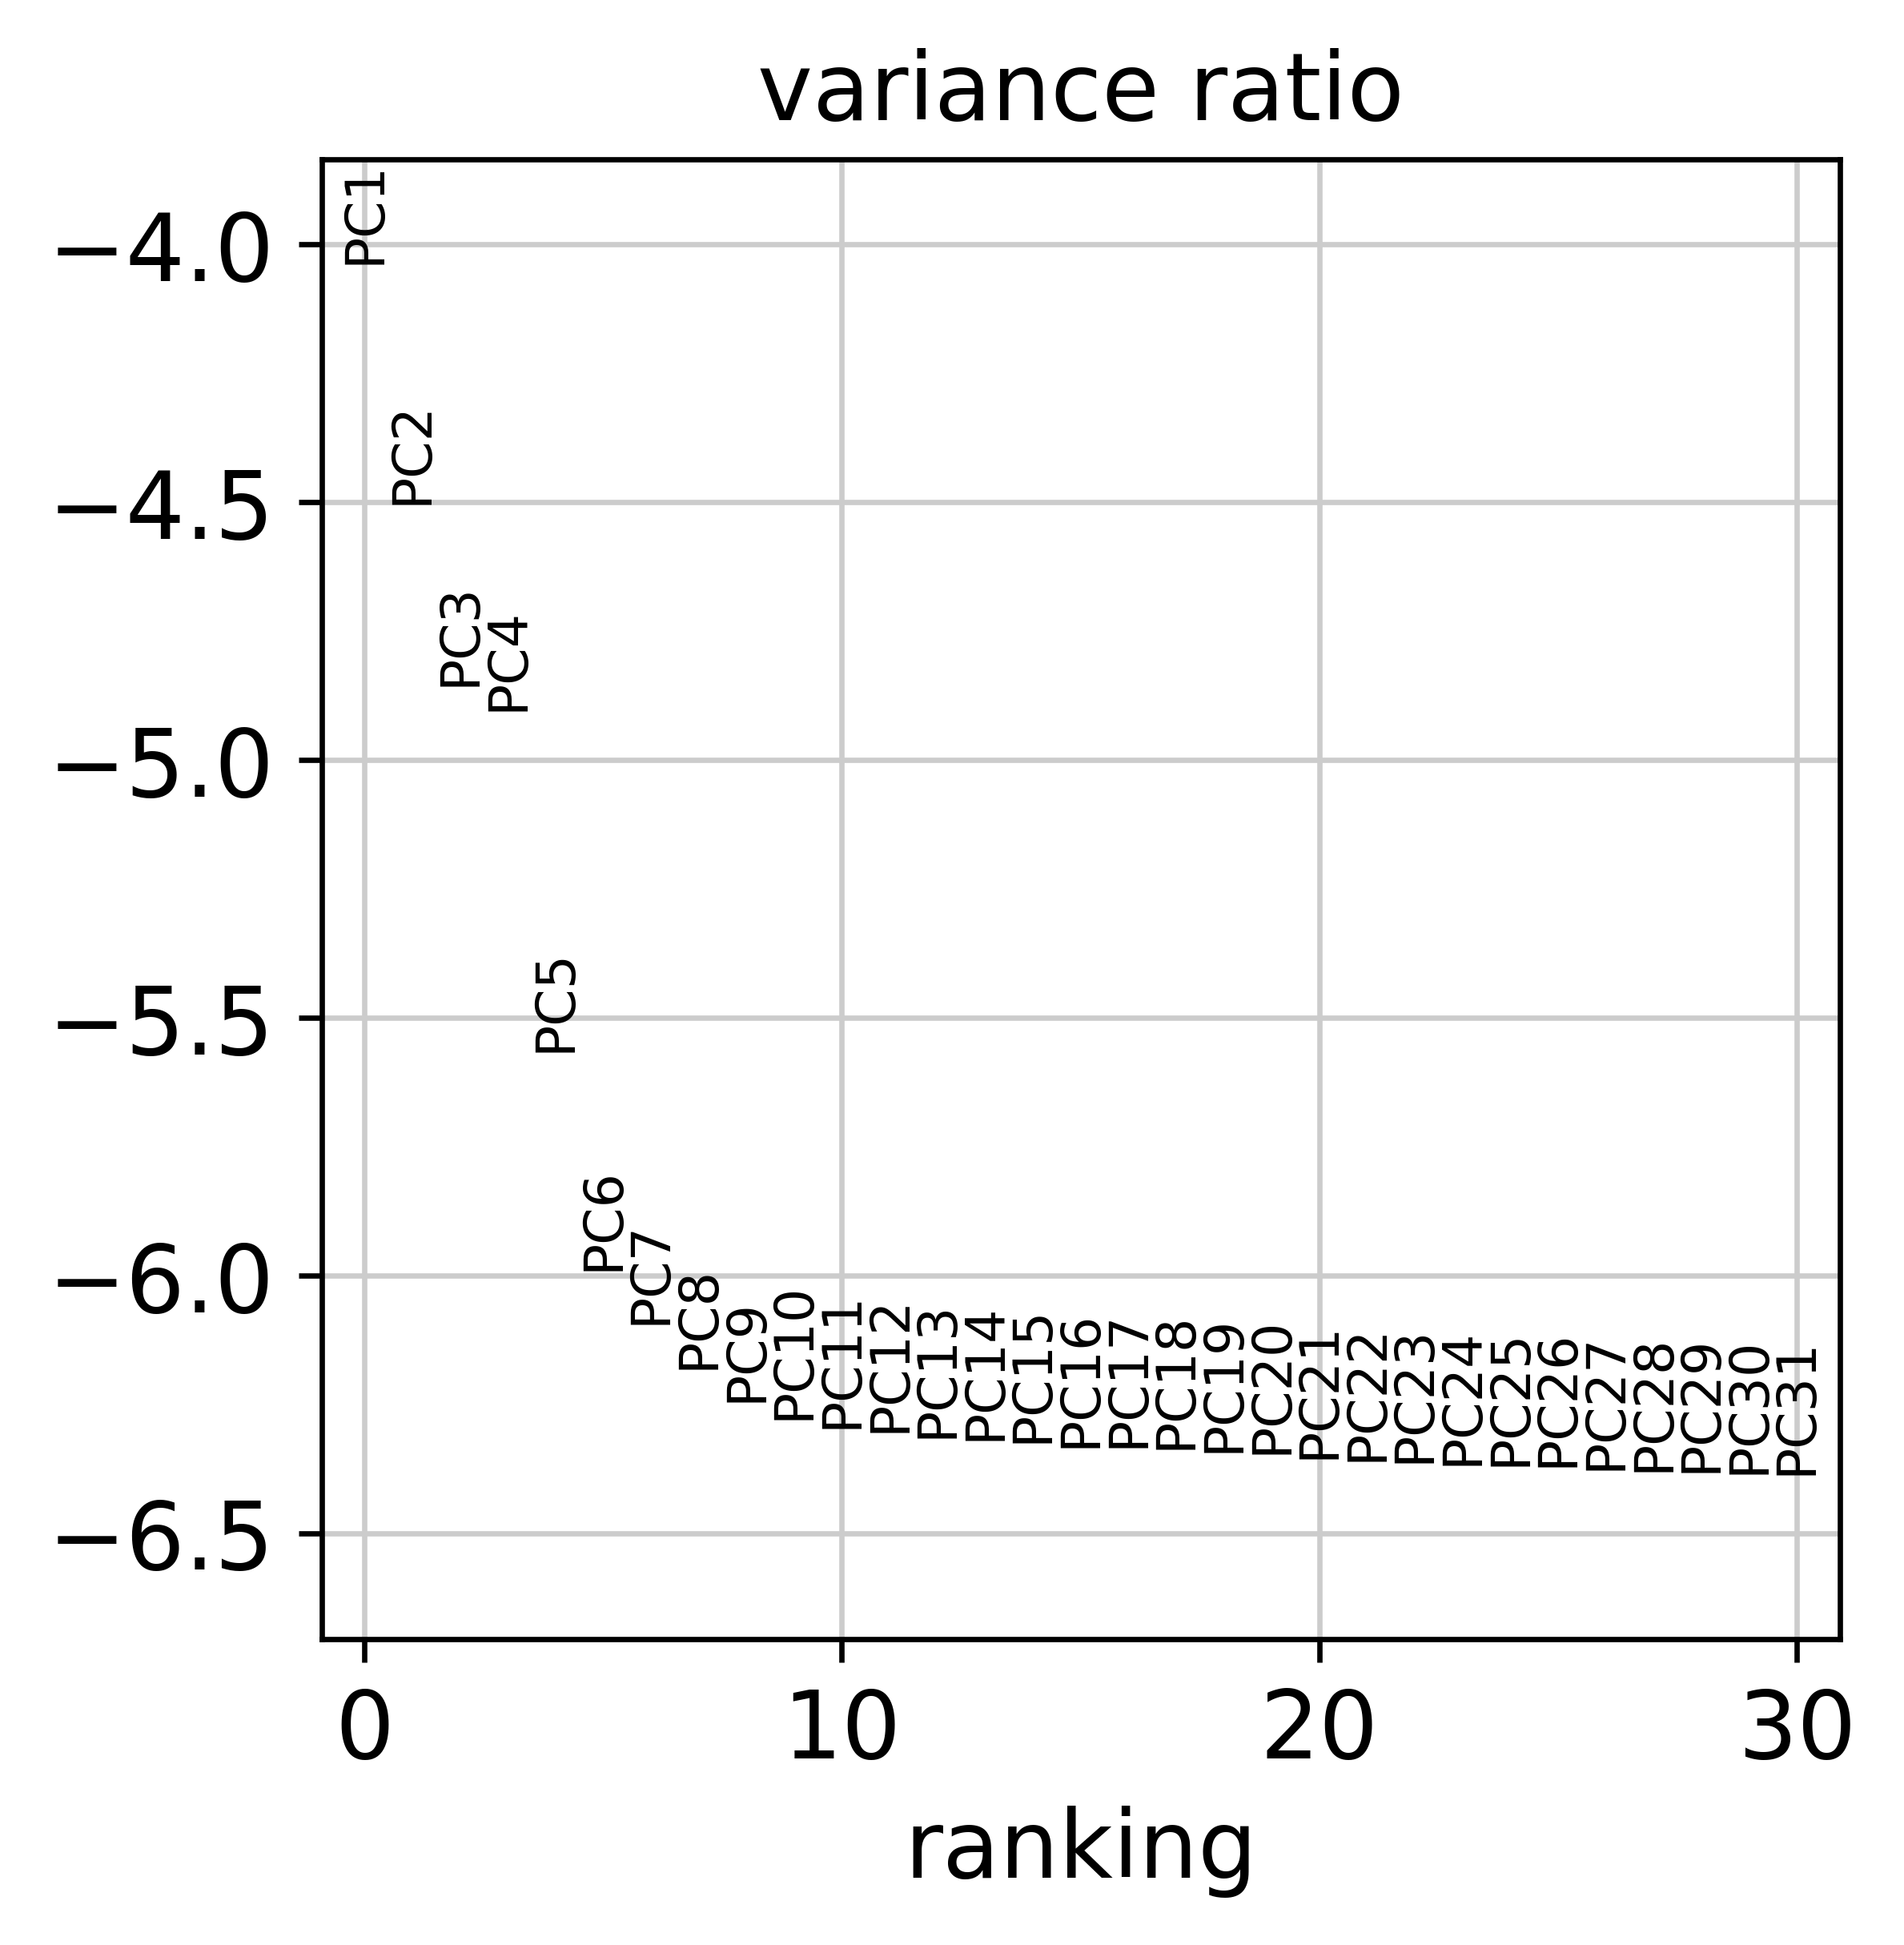

In [50]:
sc.pl.pca_variance_ratio(adata, log=True)

## 8. Save Preprocessed Data

Save the preprocessed, normalized, and PCA-reduced data object for downstream analysis.

Verify data reload works correctly: reload from disk and check n_obs, n_vars, PCA coordinates presence.

Print output path, file size in MB, and final AnnData shape.

Save preprocessed data to data/processed/adata_preprocessed.h5ad

In [51]:
output_path = "../data/processed/adata_preprocessed.h5ad"
adata.write(output_path)

In [52]:
adata_reloaded = sc.read_h5ad(output_path)

print("Shape:", adata_reloaded.shape)
print("PCA present:", "X_pca" in adata_reloaded.obsm)
print("Variance ratio present:", "pca" in adata_reloaded.uns)

Shape: (2719, 2000)
PCA present: True
Variance ratio present: True


In [53]:
import os

size_mb = os.path.getsize(output_path) / (1024**2)
print(f"Saved to: {output_path}")
print(f"File size: {size_mb:.2f} MB")
print(f"Final shape: {adata.shape}")

Saved to: ../data/processed/adata_preprocessed.h5ad
File size: 68.10 MB
Final shape: (2719, 2000)


## 9. Summary

**Preprocessing Complete**

This notebook has applied the following transformations according to the pre-registered protocol:

1. **QC Filtering**: Applied thresholds (min_genes=300, max_genes=2500, max_mito_pct=10%, min_cells_per_gene=3)
2. **Normalization**: Library size normalization to target sum 10,000 + log1p transformation
3. **HVG Selection**: Selected 2,000 highly variable genes using Seurat flavor
4. **Scaling & Regression**: Regressed out mitochondrial percentage and scaled to unit variance
5. **Dimensionality Reduction**: Computed 40 principal components

**Output**:
- Preprocessed AnnData object saved to `data/processed/adata_preprocessed.h5ad`
- Ready for downstream clustering and marker gene analysis